## Hourly Forecast Comparison - same pipeline as quarter-hourly, 24 intervals

# Part 1 - Feature Engineering

# Step 1 - Imports

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pickle
from pathlib import Path
from xgboost import XGBRegressor
from sklearn.linear_model import Lasso

plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("Imports OK")

Imports OK


# Step 2 - Load Data

In [23]:
# hourly prices (Jan 2020 to Sep 2025)
df_h = pd.read_csv("../data/clean/day_ahead_hourly_clean.csv", parse_dates=["timestamp"])
df_h = df_h.sort_values("timestamp").reset_index(drop=True)

print("Hourly shape: ", df_h.shape)
print("Hourly range: ", df_h["timestamp"].min(), "->", df_h["timestamp"].max())

Hourly shape:  (50394, 2)
Hourly range:  2020-01-01 00:00:00 -> 2025-09-30 23:00:00


# Step 3 - Load exogenous files

In [24]:
# hourly SMARD timestamp format: "Jan 16, 2025 12:00 AM"
ts_format = "%b %d, %Y %I:%M %p"

# generation forecast (wind + solar)
# cols: 0=Start, 4=Wind offshore, 5=Wind onshore, 6=PV -> same column positions as QH file
gen = pd.read_excel("../data/raw/forecasted_generation_Day-Ahead_Hour.xlsx",skiprows=9, header=0, usecols=[0, 4, 5, 6],
                    names=["timestamp", "wind_offshore_mwh", "wind_onshore_mwh", "solar_mwh"])

# consumption forecast (load)
# cols: 0=Start, 2=Grid load  -> same column positions as QH file
con = pd.read_excel("../data/raw/forecasted_consumption_Hour.xlsx", skiprows=9, header=0, usecols=[0, 2], names=["timestamp", "load_mwh"])

# parse timestamps
for df in [gen, con]:
    df["timestamp"] = pd.to_datetime(df["timestamp"], format=ts_format)

# numeric coercion
for col in ["wind_offshore_mwh", "wind_onshore_mwh", "solar_mwh"]:
    gen[col] = pd.to_numeric(gen[col], errors="coerce")
con["load_mwh"] = pd.to_numeric(con["load_mwh"], errors="coerce")

# combine wind offshore + onshore into total wind (same as QH pipeline)
gen["wind_mwh"] = gen["wind_offshore_mwh"] + gen["wind_onshore_mwh"]
gen = gen[["timestamp", "wind_mwh", "solar_mwh"]]

# remove duplicate timestamps
gen = gen.drop_duplicates(subset="timestamp", keep="first").reset_index(drop=True)
con = con.drop_duplicates(subset="timestamp", keep="first").reset_index(drop=True)

print("Generation shape:", gen.shape, "- missing:", gen.isna().sum().sum())
print("Consumption shape:", con.shape, "- missing:", con.isna().sum().sum())
print("Gen range:", gen["timestamp"].min(), "->", gen["timestamp"].max())
print("Con range:", con["timestamp"].min(), "->", con["timestamp"].max())

C:\Users\ebteh\miniconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\ebteh\miniconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Generation shape: (10942, 3) - missing: 2
Consumption shape: (10942, 2) - missing: 1
Gen range: 2024-01-01 00:00:00 -> 2025-03-31 23:00:00
Con range: 2024-01-01 00:00:00 -> 2025-03-31 23:00:00


# Step 4 - Build price lag-1-day

In [25]:
# Shift by 24 rows
df_h["price_lag1d"] = df_h["price_eur_mwh"].shift(24)

print("Lag-1-day created")
print("Missing values after lag:", df_h["price_lag1d"].isna().sum(), f"({df_h['price_lag1d'].isna().sum() / 24:.0f} days)")

Lag-1-day created
Missing values after lag: 24 (1 days)


# Step 5 - Build price lag-7-day

In [26]:
# shift 168 rows(24 x 7)
df_h["price_lag7d"] = df_h["price_eur_mwh"].shift(168)

print("Lag-7-day created")
print("Missing values after lag:", df_h["price_lag7d"].isna().sum(), f"({df_h['price_lag7d'].isna().sum() / 24:.0f} days)")

Lag-7-day created
Missing values after lag: 168 (7 days)


# Step 6 - Merge exogenous variables

In [27]:
# left join keeps all hourly price rows; attaches exogenous values where timestamps match
df_h = df_h.merge(gen, on="timestamp", how="left")
df_h = df_h.merge(con, on="timestamp", how="left")

print("After merging exogenous variables:")
print("Shape:", df_h.shape)
print("Columns:", df_h.columns.tolist())
print("Missing values per column:")
print(df_h.isna().sum())

After merging exogenous variables:
Shape: (50394, 7)
Columns: ['timestamp', 'price_eur_mwh', 'price_lag1d', 'price_lag7d', 'wind_mwh', 'solar_mwh', 'load_mwh']
Missing values per column:
timestamp            0
price_eur_mwh        0
price_lag1d         24
price_lag7d        168
wind_mwh         39453
solar_mwh        39453
load_mwh         39453
dtype: int64


# Step 7 - Keep only complete 24-hour days and fill DST gap
clock-change days (e.g., 27 Oct 2024) have 25 hours in the raw SMARD data

In [28]:
df_h["date"] = df_h["timestamp"].dt.date
counts = df_h.groupby("date").size()
df_h = df_h[df_h["date"].isin(counts[counts == 24].index)].reset_index(drop=True)

# forward-fill any remaining missing exogenous values (DST gap)
df_h[["wind_mwh", "solar_mwh", "load_mwh"]] = (df_h[["wind_mwh", "solar_mwh", "load_mwh"]].ffill())

print("After complete-day filter:")
print("Shape:", df_h.shape)
print("Missing exogenous:", df_h[["wind_mwh","solar_mwh","load_mwh"]].isna().sum().sum())

After complete-day filter:
Shape: (50256, 8)
Missing exogenous: 104904


The hourly price file covers Jan 2020 - Sep 2025 (50,394 rows). And the exogenous files only cover Jan 2024 – Mar 2025 (10,942 rows). 
    So all the hours from 2020–2023 have no wind/solar/load match after the merge - that is where the 104,904 NaNs come from

# Step 8- Drop rows with missing values

In [29]:
features = ["price_lag1d", "price_lag7d", "wind_mwh", "solar_mwh", "load_mwh"]
target   = "price_eur_mwh"

before = len(df_h)
df_h = df_h.dropna(subset=features + [target]).reset_index(drop=True)
after  = len(df_h)

print(f"Rows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Dropped:     {before - after} rows ({(before - after) / 24:.0f} days)")
print(f"Remaining:   {after / 24:.0f} complete days")
print(f"Date range:  {df_h['timestamp'].min()} → {df_h['timestamp'].max()}")

Rows before: 50,256
Rows after:  15,288
Dropped:     34968 rows (1457 days)
Remaining:   637 complete days
Date range:  2024-01-01 00:00:00 → 2025-09-30 23:00:00


# Step 9 - Select the winter test window and save split files

In [30]:
n_train    = 100
test_start = pd.Timestamp("2025-01-16").date()
test_end   = pd.Timestamp("2025-02-28").date()

all_days   = sorted(df_h["date"].unique())
test_days  = [d for d in all_days if test_start <= d <= test_end]
first_idx  = all_days.index(test_days[0])
train_days = all_days[first_idx - n_train : first_idx]

assert len(train_days) == n_train, f"Expected 100 train days, got {len(train_days)}"
assert len(test_days)  == 44,      f"Expected 44 test days, got {len(test_days)}"
assert (pd.Timestamp(test_days[0]) - pd.Timestamp(train_days[-1])).days == 1, \
    "Gap between train and test is not exactly 1 day"

# keep only train + test days
df_split = df_h[df_h["date"].isin(train_days + test_days)].reset_index(drop=True)

n_test  = len(test_days)   # 44
n_total = len(train_days) + len(test_days)  # 144

print("TRAIN – TEST SPLIT SUMMARY")
print(f"  Training window : {len(train_days)} days  ({train_days[0]} → {train_days[-1]})")
print(f"  Test window     : {len(test_days)} days  ({test_days[0]} → {test_days[-1]})")
print(f"  Total rows      : {len(df_split):,}  ({n_total} days × 24)")

TRAIN – TEST SPLIT SUMMARY
  Training window : 100 days  (2024-10-08 → 2025-01-15)
  Test window     : 44 days  (2025-01-16 → 2025-02-28)
  Total rows      : 3,456  (144 days × 24)


# Step 10 - Final feature matrix summary

In [31]:
print(" FINAL FEATURE MATRIX (HOURLY)")
print(f"Rows (observations) : {len(df_split):,}")
print(f"Target variable : 1  (price_eur_mwh)")
print(f"Lag features    : 2  (price_lag1d, price_lag7d)")
print(f"Exogenous       : 3  (wind_mwh, solar_mwh, load_mwh)")
print()
print(df_split[features + [target]].describe().round(2).T.to_string())

 FINAL FEATURE MATRIX (HOURLY)
Rows (observations) : 3,456
Target variable : 1  (price_eur_mwh)
Lag features    : 2  (price_lag1d, price_lag7d)
Exogenous       : 3  (wind_mwh, solar_mwh, load_mwh)

                count      mean       std       min       25%       50%       75%       max
price_lag1d    3456.0    110.97     65.06    -15.69     82.50    107.53    131.54    936.28
price_lag7d    3456.0    109.71     65.27    -15.69     81.03    106.26    130.12    936.28
wind_mwh       3456.0  17717.81  12565.72    248.25   7026.44  14808.00  27012.44  50325.00
solar_mwh      3456.0   3056.75   5666.13      0.00      0.00      0.00   3939.12  34376.75
load_mwh       3456.0  55791.13   9045.31  36347.75  48408.50  55125.88  64339.75  73417.00
price_eur_mwh  3456.0    111.28     64.91    -15.69     82.82    108.00    131.88    936.28


#  Step 11 - Build model arrays

In [32]:
nintervals = 24

X_all = df_split[features].values   # (3456, 5)
y_all = df_split[target].values     # (3456,)

train_end   = n_train * nintervals
y_test_orig = y_all[train_end:].reshape(n_test, nintervals)

print(f"X_all       : {X_all.shape}")
print(f"y_all       : {y_all.shape}")
print(f"y_test_orig : {y_test_orig.shape}  ({n_test} days × {nintervals} intervals)")

X_all       : (3456, 5)
y_all       : (3456,)
y_test_orig : (44, 24)  (44 days × 24 intervals)


# Part 2 - LEAR

# Step 1 - LEAR Configuration
- Part A: Regularisation parameter `alpha` sensitivity - 4-window averaging scheme
- Part B: Window scheme comparison - 4-window averaging vs single expanding window

Same alpha grid and windows as `LEAR.ipynb` in the QH thesis

In [34]:
lasso_max_iter = 10000
windows        = [100, 84, 56, 28]
alphas         = [0.001, 0.0034079864342526534, 0.01, 0.1]

print(f"Windows : {windows} days")
print(f"Alphas  : {alphas}")

Windows : [100, 84, 56, 28] days
Alphas  : [0.001, 0.0034079864342526534, 0.01, 0.1]


# Step 2 -  LEAR Helper: standardize, fit, predict for one window

In [35]:
def lear_fit_and_predict(X_all, y_all, row_start, row_end, row_pred,
                         alpha, max_iter=lasso_max_iter, nintervals=nintervals):
    X_tr = X_all[row_start:row_end, :]
    y_tr = y_all[row_start:row_end]

    mean_X = X_tr.mean(axis=0)
    std_X  = X_tr.std(axis=0)
    std_X[std_X == 0] = 1.0

    mean_y = y_tr.mean()
    std_y  = y_tr.std()
    if std_y == 0:
        std_y = 1.0

    X_tr_sc = (X_tr - mean_X) / std_X
    y_tr_sc = (y_tr - mean_y) / std_y
    X_te_sc = (X_all[row_pred:row_pred + nintervals, :] - mean_X) / std_X

    reg = Lasso(alpha=alpha, max_iter=max_iter, fit_intercept=True)
    reg.fit(X_tr_sc, y_tr_sc)
    pred_sc = reg.predict(X_te_sc)

    return pred_sc * std_y + mean_y

print("LEAR helper defined")

LEAR helper defined


# Step 3 - LEAR Part A: Alpha comparison (4-window averaging)

In [36]:
lear_alpha_results = {}
lear_alpha_preds   = {}

for alpha_val in alphas:
    alpha_name = f"alpha_{alpha_val}"
    print(f"\n{alpha_name}")

    all_preds = np.zeros((n_test, nintervals))

    for i in range(n_test):
        forecast_day_idx = n_train + i
        row_pred = forecast_day_idx * nintervals

        window_preds = []
        for w in windows:
            row_end   = forecast_day_idx * nintervals
            row_start = max(forecast_day_idx - w, 0) * nintervals
            window_preds.append(
                lear_fit_and_predict(X_all, y_all, row_start, row_end, row_pred, alpha_val)
            )

        all_preds[i, :] = np.mean(window_preds, axis=0)

    errors = y_test_orig - all_preds
    mae  = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))

    lear_alpha_results[alpha_name] = {"MAE": round(mae, 4), "RMSE": round(rmse, 4)}
    lear_alpha_preds[alpha_name]   = all_preds
    print(f"  -> MAE: {mae:.4f}  RMSE: {rmse:.4f} EUR/MWh")

print("\nAll alpha configurations done")


alpha_0.001
  -> MAE: 19.0660  RMSE: 27.5240 EUR/MWh

alpha_0.0034079864342526534
  -> MAE: 18.9358  RMSE: 27.4239 EUR/MWh

alpha_0.01
  -> MAE: 18.5930  RMSE: 27.1664 EUR/MWh

alpha_0.1
  -> MAE: 17.0066  RMSE: 27.7021 EUR/MWh

All alpha configurations done


# Step 4 - LEAR Regularisation comparison table

In [37]:
print("LEAR Hourly — Regularisation Parameter Comparison (4-window averaging)")
print(f"  {'Configuration':<44} {'MAE':>8} {'RMSE':>8}")
for name, r in lear_alpha_results.items():
    print(f"  {name:<44} {r['MAE']:>8.4f} {r['RMSE']:>8.4f}")

lear_best_alpha     = min(lear_alpha_results, key=lambda x: lear_alpha_results[x]["MAE"])
lear_best_alpha_val = float(lear_best_alpha.split("alpha_")[1])

print(f"\nBest alpha (lowest MAE): {lear_best_alpha}")
print(f"Best alpha value       : {lear_best_alpha_val}")

LEAR Hourly — Regularisation Parameter Comparison (4-window averaging)
  Configuration                                     MAE     RMSE
  alpha_0.001                                   19.0660  27.5240
  alpha_0.0034079864342526534                   18.9358  27.4239
  alpha_0.01                                    18.5930  27.1664
  alpha_0.1                                     17.0066  27.7021

Best alpha (lowest MAE): alpha_0.1
Best alpha value       : 0.1


# Step 5 - LEAR Part B: Expanding-window evaluation
Use best alpha

In [38]:
print(f"Using best alpha: {lear_best_alpha_val}")
print(f"Running expanding-window evaluation ({n_test} test days)")

lear_pred_expanding = np.zeros((n_test, nintervals))

for i in range(n_test):
    forecast_day_idx = n_train + i
    row_end  = forecast_day_idx * nintervals
    row_pred = forecast_day_idx * nintervals

    lear_pred_expanding[i, :] = lear_fit_and_predict(
        X_all, y_all,
        row_start=0,
        row_end=row_end,
        row_pred=row_pred,
        alpha=lear_best_alpha_val,
    )

    if (i + 1) % 10 == 0 or i == 0:
        print(f"  Day {i+1:>2d}/44 - trained on {forecast_day_idx} days ({row_end} observations)")

errors_exp     = y_test_orig - lear_pred_expanding
lear_mae_exp   = float(np.mean(np.abs(errors_exp)))
lear_rmse_exp  = float(np.sqrt(np.mean(errors_exp ** 2)))

print(f"\nExpanding window -> MAE: {lear_mae_exp:.4f}  RMSE: {lear_rmse_exp:.4f} EUR/MWh")

Using best alpha: 0.1
Running expanding-window evaluation (44 test days)
  Day  1/44 - trained on 100 days (2400 observations)
  Day 10/44 - trained on 109 days (2616 observations)
  Day 20/44 - trained on 119 days (2856 observations)
  Day 30/44 - trained on 129 days (3096 observations)
  Day 40/44 - trained on 139 days (3336 observations)

Expanding window -> MAE: 15.8923  RMSE: 27.0350 EUR/MWh


# Step 6 - LEAR  Window scheme comparison

In [39]:
lear_best_4w = lear_alpha_results[lear_best_alpha]

print(f"LEAR Hourly — Window Scheme Comparison (using {lear_best_alpha})")
print(f"  {'Scheme':<30} {'MAE':>8} {'RMSE':>8}")
print(f"  {'4-window averaging':<30} {lear_best_4w['MAE']:>8.4f} {lear_best_4w['RMSE']:>8.4f}")
print(f"  {'Expanding window':<30} {lear_mae_exp:>8.4f} {lear_rmse_exp:>8.4f}")

LEAR Hourly — Window Scheme Comparison (using alpha_0.1)
  Scheme                              MAE     RMSE
  4-window averaging              17.0066  27.7021
  Expanding window                15.8923  27.0350


# Step 7 - LEAR Forecast plot
first 7 test days

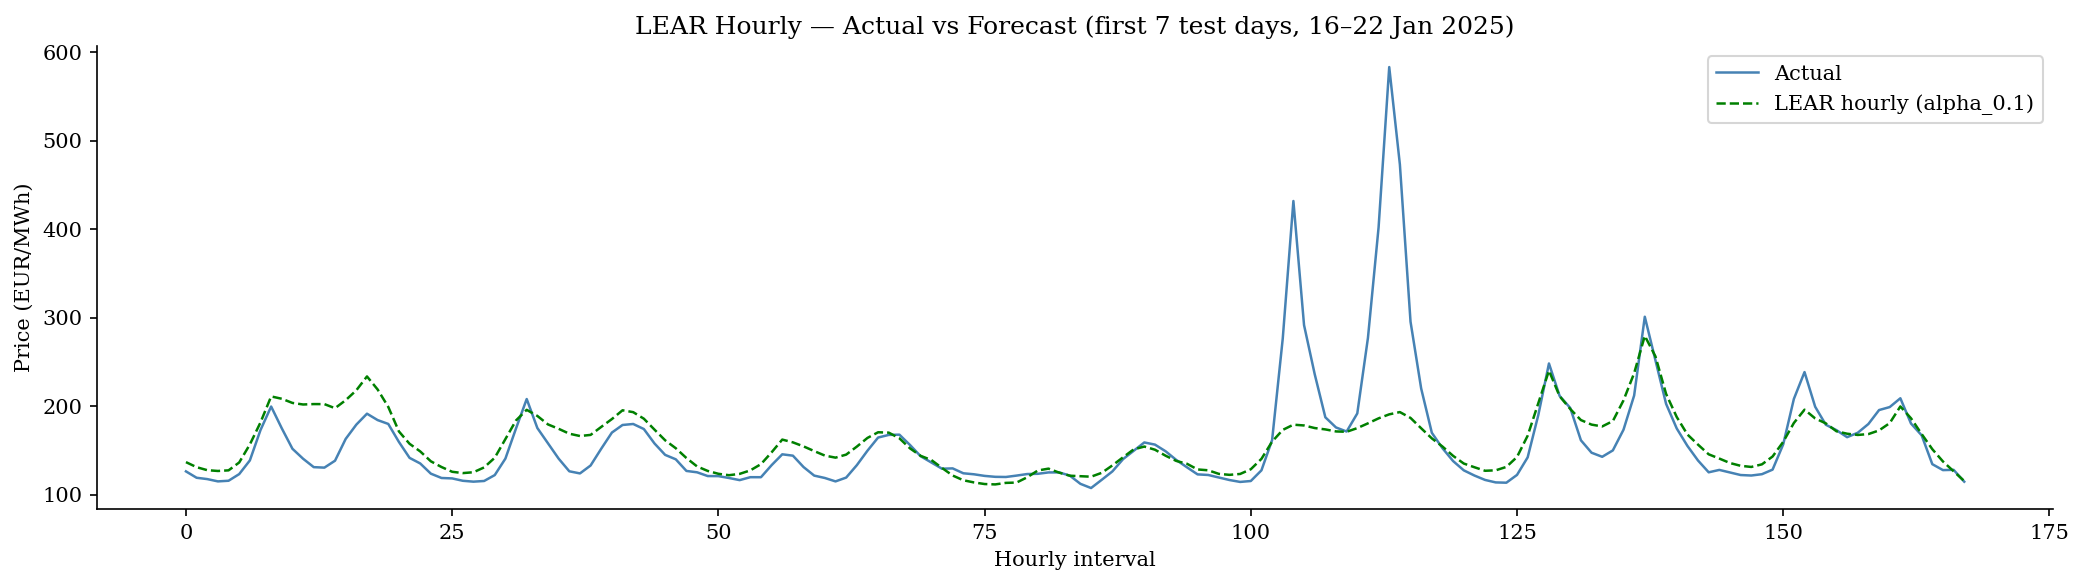

Plot done


In [40]:
lear_best_pred = lear_alpha_preds[lear_best_alpha]
n_plot         = 7 * nintervals

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_test_orig.flatten()[:n_plot],    label="Actual",
        linewidth=1.2, color="steelblue")
ax.plot(lear_best_pred.flatten()[:n_plot], label=f"LEAR hourly ({lear_best_alpha})",
        linewidth=1.2, color="green", linestyle="--")
ax.set_title("LEAR Hourly — Actual vs Forecast (first 7 test days, 16–22 Jan 2025)")
ax.set_xlabel("Hourly interval")
ax.set_ylabel("Price (EUR/MWh)")
ax.legend()
plt.tight_layout()
plt.show()
print("Plot done")

# Part 3 - XGBoost

# Step 1 - Configuration

- Part A: Hyperparameter sensitivity — 4-window averaging scheme
- Part B: Window scheme comparison — 4-window averaging vs single expanding window

Same four configurations and windows as `XGBoost.ipynb` in the QH thesis

In [41]:
random_state = 42

configs = {
    "Baseline": dict(
        n_estimators     = 444,
        learning_rate    = 0.020834136992346326,
        max_depth        = 4,
        min_child_weight = 6,
        subsample        = 0.6646124229308177,
        colsample_bytree = 0.6061035603483517,
        gamma            = 0.008910429703573388,
        reg_alpha        = 0.14968119527801219,
        reg_lambda       = 0.26277200687034197,
        random_state     = random_state,
    ),
    "Config A": dict(
        n_estimators=100, learning_rate=0.1, max_depth=4, min_child_weight=6,
        subsample=0.8, colsample_bytree=0.8, gamma=0.0,
        reg_alpha=0.0, reg_lambda=1.0, random_state=random_state,
    ),
    "Config B": dict(
        n_estimators=200, learning_rate=0.05, max_depth=6, min_child_weight=3,
        subsample=1.0, colsample_bytree=1.0, gamma=0.0,
        reg_alpha=0.0, reg_lambda=1.0, random_state=random_state,
    ),
    "Config C": dict(
        n_estimators=100, learning_rate=0.1, max_depth=3, min_child_weight=1,
        subsample=1.0, colsample_bytree=1.0, gamma=0.0,
        reg_alpha=0.0, reg_lambda=1.0, random_state=random_state,
    ),
}

print(f"Configurations: {list(configs.keys())}")
print(f"Windows        : {windows} days")

Configurations: ['Baseline', 'Config A', 'Config B', 'Config C']
Windows        : [100, 84, 56, 28] days


# Step 2 - XGBoost Helper: standardise, fit, predict for one window

In [42]:
def xgb_fit_and_predict(X_all, y_all, row_start, row_end, row_pred,
                        params, nintervals=nintervals):
    X_tr = X_all[row_start:row_end, :]
    y_tr = y_all[row_start:row_end]

    mean_X = X_tr.mean(axis=0)
    std_X  = X_tr.std(axis=0)
    std_X[std_X == 0] = 1.0

    mean_y = y_tr.mean()
    std_y  = y_tr.std()
    if std_y == 0:
        std_y = 1.0

    X_tr_sc = (X_tr - mean_X) / std_X
    y_tr_sc = (y_tr - mean_y) / std_y
    X_te_sc = (X_all[row_pred:row_pred + nintervals, :] - mean_X) / std_X

    model = XGBRegressor(**params)
    model.fit(X_tr_sc, y_tr_sc)
    pred_sc = model.predict(X_te_sc)

    return pred_sc * std_y + mean_y

print("XGBoost helper defined")

XGBoost helper defined


# Step 3 : XGBoost Part A: Hyperparameter comparison (4-window averaging)

In [43]:
xgb_config_results = {}
xgb_config_preds   = {}

for config_name, params in configs.items():
    print(f"\n{config_name}")

    all_preds = np.zeros((n_test, nintervals))

    for i in range(n_test):
        forecast_day_idx = n_train + i
        row_pred = forecast_day_idx * nintervals

        window_preds = []
        for w in windows:
            row_end   = forecast_day_idx * nintervals
            row_start = max(forecast_day_idx - w, 0) * nintervals
            window_preds.append(
                xgb_fit_and_predict(X_all, y_all, row_start, row_end, row_pred, params)
            )

        all_preds[i, :] = np.mean(window_preds, axis=0)

    errors = y_test_orig - all_preds
    mae  = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))

    xgb_config_results[config_name] = {"MAE": round(mae, 4), "RMSE": round(rmse, 4)}
    xgb_config_preds[config_name]   = all_preds
    print(f"  -> MAE: {mae:.4f}  RMSE: {rmse:.4f} EUR/MWh")

print("\nAll configurations done")


Baseline
  -> MAE: 16.7242  RMSE: 26.1446 EUR/MWh

Config A
  -> MAE: 16.1735  RMSE: 25.7120 EUR/MWh

Config B
  -> MAE: 15.5516  RMSE: 25.0345 EUR/MWh

Config C
  -> MAE: 16.6300  RMSE: 26.2137 EUR/MWh

All configurations done


# Step 4 - Hyperparameter comparison table

In [44]:
print("XGBoost Hourly — Hyperparameter Comparison (4-window averaging)")
print(f"  {'Configuration':<38} {'MAE':>8} {'RMSE':>8}")
for name, r in xgb_config_results.items():
    print(f"  {name:<38} {r['MAE']:>8.4f} {r['RMSE']:>8.4f}")

xgb_best_config = min(xgb_config_results, key=lambda x: xgb_config_results[x]["MAE"])
xgb_best_params = configs[xgb_best_config]

print(f"\nBest configuration (lowest MAE): {xgb_best_config}")

XGBoost Hourly — Hyperparameter Comparison (4-window averaging)
  Configuration                               MAE     RMSE
  Baseline                                16.7242  26.1446
  Config A                                16.1735  25.7120
  Config B                                15.5516  25.0345
  Config C                                16.6300  26.2137

Best configuration (lowest MAE): Config B


# Step 5 - XGBoost Part B: Expanding-window evaluation
best configuration

In [45]:
print(f"Window scheme comparison using {xgb_best_config}")
print(f"Running expanding-window evaluation ({n_test} test days)...")

xgb_pred_expanding = np.zeros((n_test, nintervals))

for i in range(n_test):
    forecast_day_idx = n_train + i
    row_end  = forecast_day_idx * nintervals
    row_pred = forecast_day_idx * nintervals

    xgb_pred_expanding[i, :] = xgb_fit_and_predict(
        X_all, y_all,
        row_start=0,
        row_end=row_end,
        row_pred=row_pred,
        params=xgb_best_params,
    )

    if (i + 1) % 10 == 0 or i == 0:
        print(f"  Day {i+1:>2d}/44 — trained on {forecast_day_idx} days ({row_end} observations)")

errors_exp    = y_test_orig - xgb_pred_expanding
xgb_mae_exp   = float(np.mean(np.abs(errors_exp)))
xgb_rmse_exp  = float(np.sqrt(np.mean(errors_exp ** 2)))

print(f"\nExpanding window -> MAE: {xgb_mae_exp:.4f}  RMSE: {xgb_rmse_exp:.4f} EUR/MWh")

Window scheme comparison using Config B
Running expanding-window evaluation (44 test days)...
  Day  1/44 — trained on 100 days (2400 observations)
  Day 10/44 — trained on 109 days (2616 observations)
  Day 20/44 — trained on 119 days (2856 observations)
  Day 30/44 — trained on 129 days (3096 observations)
  Day 40/44 — trained on 139 days (3336 observations)

Expanding window -> MAE: 15.8463  RMSE: 25.4344 EUR/MWh


# Step 6 - Window scheme comparison

In [46]:
xgb_best_4w = xgb_config_results[xgb_best_config]

print(f"XGBoost Hourly — Window Scheme Comparison ({xgb_best_config})")
print(f"  {'Scheme':<30} {'MAE':>8} {'RMSE':>8}")
print(f"  {'4-window averaging':<30} {xgb_best_4w['MAE']:>8.4f} {xgb_best_4w['RMSE']:>8.4f}")
print(f"  {'Expanding window':<30} {xgb_mae_exp:>8.4f} {xgb_rmse_exp:>8.4f}")

XGBoost Hourly — Window Scheme Comparison (Config B)
  Scheme                              MAE     RMSE
  4-window averaging              15.5516  25.0345
  Expanding window                15.8463  25.4344


# Step 7: Forecast plot
first 7 test days

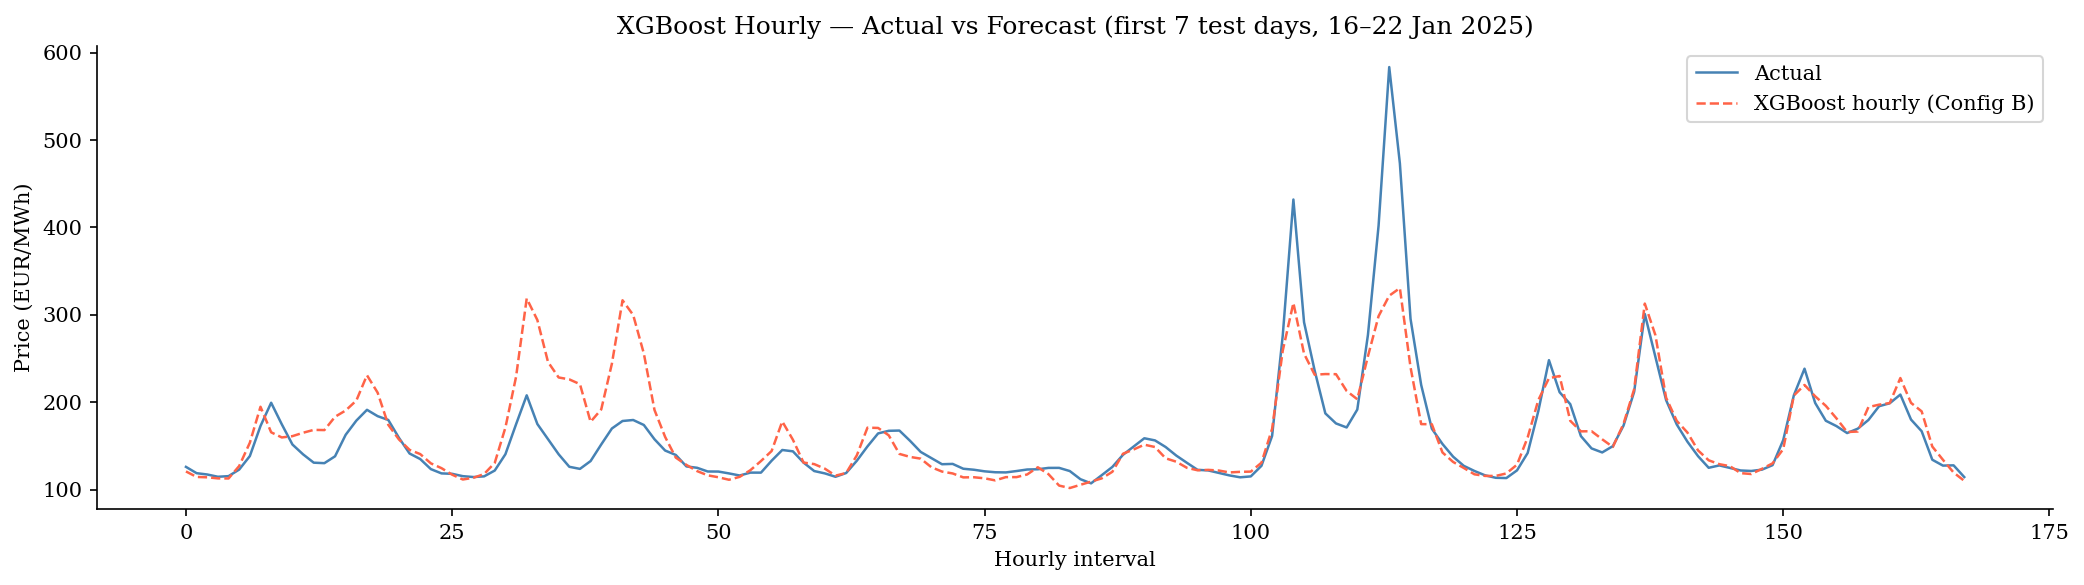

Plot done


In [47]:
xgb_best_pred = xgb_config_preds[xgb_best_config]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_test_orig.flatten()[:n_plot],   label="Actual",
        linewidth=1.2, color="steelblue")
ax.plot(xgb_best_pred.flatten()[:n_plot], label=f"XGBoost hourly ({xgb_best_config})",
        linewidth=1.2, color="tomato", linestyle="--")
ax.set_title("XGBoost Hourly — Actual vs Forecast (first 7 test days, 16–22 Jan 2025)")
ax.set_xlabel("Hourly interval")
ax.set_ylabel("Price (EUR/MWh)")
ax.legend()
plt.tight_layout()
plt.show()
print("Plot done")

# Part 4 - SUMMARY

# Granularity comparison table

Hourly results (this notebook, 4-window best config) vs quarter-hourly thesis results

In [49]:
lear_hourly_mae  = lear_alpha_results[lear_best_alpha]["MAE"]
lear_hourly_rmse = lear_alpha_results[lear_best_alpha]["RMSE"]
xgb_hourly_mae   = xgb_config_results[xgb_best_config]["MAE"]
xgb_hourly_rmse  = xgb_config_results[xgb_best_config]["RMSE"]

# QH thesis results (fixed)
lear_qh_mae,  lear_qh_rmse  = 12.06, 16.08
xgb_qh_mae,   xgb_qh_rmse   = 11.55, 16.27

print("GRANULARITY COMPARISON — same pipeline, same test window (44 days)")
print()
print(f"{'Model':<10} {'Resolution':<16} {'Best config':<35} {'MAE':>8} {'RMSE':>8}")
print("-" * 82)
print(f"{'LEAR':<10} {'Quarter-hourly':<16} {'alpha=0.01':<35} {lear_qh_mae:>8.2f} {lear_qh_rmse:>8.2f}")
print(f"{'LEAR':<10} {'Hourly':<16} {lear_best_alpha:<35} {lear_hourly_mae:>8.2f} {lear_hourly_rmse:>8.2f}")
print("-" * 82)
print(f"{'XGBoost':<10} {'Quarter-hourly':<16} {'Baseline (Lebedev et al.)':<35} {xgb_qh_mae:>8.2f} {xgb_qh_rmse:>8.2f}")
print(f"{'XGBoost':<10} {'Hourly':<16} {xgb_best_config:<35} {xgb_hourly_mae:>8.2f} {xgb_hourly_rmse:>8.2f}")

GRANULARITY COMPARISON — same pipeline, same test window (44 days)

Model      Resolution       Best config                              MAE     RMSE
----------------------------------------------------------------------------------
LEAR       Quarter-hourly   alpha=0.01                             12.06    16.08
LEAR       Hourly           alpha_0.1                              17.01    27.70
----------------------------------------------------------------------------------
XGBoost    Quarter-hourly   Baseline (Lebedev et al.)              11.55    16.27
XGBoost    Hourly           Config B                               15.55    25.03
